# 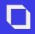 IONCOR Oy Scrap Value Forecasting Dashboard (Random Forest Regressor,XGBoost, ARIMA, LSTM, Prophet)

## 📦 Import, Load libraries and packages

In [1]:
import pandas as pd
import numpy as np
import panel as pn
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from statsmodels.tsa.arima.model import ARIMA
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from prophet import Prophet
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings("ignore")
pn.extension()

## ⚙️ Define Files and Preprocessing Function

In [2]:
def preprocess_time_series(file_path):
    df = pd.read_excel(file_path)
    df = df[["Posting Date", "Amount in LC"]]
    df = df.groupby("Posting Date").sum().reset_index()
    df = df.sort_values("Posting Date")
    df.dropna(inplace=True)
    return df

## 📁 Uploaded Files and Setup

In [3]:
file_dict = {
    "Cell_1_y7": "Desktop/Thesis_project/Thesis_Test_ML/Cell_1_y7.XLSX",
    "BDU_Y7": "Desktop/Thesis_project/Thesis_Test_ML/BDU_Y7.XLSX",
    "BMS_48": "Desktop/Thesis_project/Thesis_Test_ML/BMS_48.XLSX",
    "Converter_48": "Desktop/Thesis_project/Thesis_Test_ML/Converter_48.XLSX",
    "Base_Tray_vent_Y7": "Desktop/Thesis_project/Thesis_Test_ML/Base_Tray_vent_Y7.XLSX",
    "BMU_Y7": "Desktop/Thesis_project/Thesis_Test_ML/BMU_Y7.XLSX",
    "Cell_48": "Desktop/Thesis_project/Thesis_Test_ML/Cell_48.XLSX",
    "Cooler_48": "Desktop/Thesis_project/Thesis_Test_ML/Cooler_48.XLSX",
    "Busbar1_Y7": "Desktop/Thesis_project/Thesis_Test_ML/Busbar1_Y7.XLSX",
    "Cover_Y7": "Desktop/Thesis_project/Thesis_Test_ML/Cover_Y7.XLSX",
    "Cell_3_y7": "Desktop/Thesis_project/Thesis_Test_ML/Cell_3_y7.XLSX",
    "Circuit_board_Sensor_48": "Desktop/Thesis_project/Thesis_Test_ML/Circuit_board_Sensor_48.XLSX",
    "ZELLBLOCK_RE_Uki": "Desktop/Thesis_project/Thesis_Test_ML/ZELLBLOCK_RE_Uki.XLSX",
    "ZELLBLOCK_LI_Uki": "Desktop/Thesis_project/Thesis_Test_ML/ZELLBLOCK_LI_Uki.XLSX",
    "LI_ION_Cell_Uki": "Desktop/Thesis_project/Thesis_Test_ML/LI_ION_Cell_Uki.XLSX",
    "Prismatic_Cell_Uki": "Desktop/Thesis_project/Thesis_Test_ML/Prismatic_Cell_Uki.XLSX"
}


## 🧠 XGBoost Prediction

In [4]:
def xgboost_forecast(df):
    df['Year'] = df['Posting Date'].dt.year
    df['Month'] = df['Posting Date'].dt.month
    df['Day'] = df['Posting Date'].dt.day
    df['DayOfWeek'] = df['Posting Date'].dt.dayofweek
    df['DayOfYear'] = df['Posting Date'].dt.dayofyear
    
    X = df[['Year', 'Month', 'Day', 'DayOfWeek', 'DayOfYear']]
    y = df['Amount in LC']
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
    
    model = XGBRegressor(n_estimators=200, learning_rate=0.1)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    rmse = mean_squared_error(y_test, y_pred, squared=False)
    return y_test.reset_index(drop=True), y_pred, rmse

## 🔁 Random Forest Forecasting

In [5]:
def random_forest_forecast(df):
    df['Year'] = df['Posting Date'].dt.year
    df['Month'] = df['Posting Date'].dt.month
    df['Day'] = df['Posting Date'].dt.day
    df['DayOfWeek'] = df['Posting Date'].dt.dayofweek
    df['DayOfYear'] = df['Posting Date'].dt.dayofyear
    
    X = df[['Year', 'Month', 'Day', 'DayOfWeek', 'DayOfYear']]
    y = df['Amount in LC']
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
    
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    rmse = mean_squared_error(y_test, y_pred, squared=False)
    return y_test.reset_index(drop=True), y_pred, rmse

## 🔁 ARIMA Forecasting

In [6]:
def arima_forecast(df):
    series = df.set_index('Posting Date')['Amount in LC']
    model = ARIMA(series, order=(5,1,0))
    model_fit = model.fit()
    forecast = model_fit.forecast(steps=int(len(series)*0.2))
    y_true = series[-len(forecast):]
    rmse = mean_squared_error(y_true, forecast, squared=False)
    return y_true, forecast, rmse

## 🔮 Prophet Forecasting

In [7]:
def prophet_forecast(df):
    df_prophet = df.rename(columns={'Posting Date': 'ds', 'Amount in LC': 'y'})
    
    train_size = int(len(df_prophet) * 0.8)
    train, test = df_prophet.iloc[:train_size], df_prophet.iloc[train_size:]
    
    model = Prophet()
    model.fit(train)
    
    future = model.make_future_dataframe(periods=len(test))
    forecast = model.predict(future)
    
    y_pred = forecast['yhat'].iloc[train_size:]
    y_true = test['y'].reset_index(drop=True)
    
    rmse = mean_squared_error(y_true, y_pred, squared=False)
    return y_true, y_pred, rmse


## 🤖 LSTM Forecasting

### Prepare data

In [8]:
def lstm_forecast(df):
    # 1. Prepare the data
    data = df['Amount in LC'].values.reshape(-1, 1)
    scaler = MinMaxScaler(feature_range=(0, 1))
    data_scaled = scaler.fit_transform(data)
    
    # 2. Create dataset function (should be inside lstm_forecast)
    def create_dataset(dataset, look_back=1):
        X, Y = [], []
        for i in range(len(dataset)-look_back-1):
            a = dataset[i:(i+look_back), 0]
            X.append(a)
            Y.append(dataset[i + look_back, 0])
        return np.array(X), np.array(Y)
    
    # 3. Create sequences
    look_back = 3
    X, y = create_dataset(data_scaled, look_back)
    
    # 4. Split data
    train_size = int(len(X) * 0.8)
    X_train, X_test = X[:train_size], X[train_size:]
    y_train, y_test = y[:train_size], y[train_size:]
    
    # 5. Reshape for LSTM
    X_train = np.reshape(X_train, (X_train.shape[0], 1, X_train.shape[1]))
    X_test = np.reshape(X_test, (X_test.shape[0], 1, X_test.shape[1]))
    
    # 6. Build and train model
    model = Sequential()
    model.add(LSTM(50, input_shape=(1, look_back)))
    model.add(Dense(1))
    model.compile(loss='mean_squared_error', optimizer='adam')
    model.fit(X_train, y_train, epochs=20, batch_size=1, verbose=0)
    
    # 7. Make predictions
    y_pred_scaled = model.predict(X_test)
    y_pred = scaler.inverse_transform(y_pred_scaled)
    y_true = scaler.inverse_transform(y_test.reshape(-1, 1))
    
    # 8. Calculate RMSE
    rmse = mean_squared_error(y_true, y_pred, squared=False)
    return y_true.flatten(), y_pred.flatten(), rmse

## 📊 Plotting function

In [9]:
def create_plot(y_true, y_pred, model_name):
    plt.figure(figsize=(10,5))
    plt.plot(y_true.values if hasattr(y_true, 'values') else y_true, label='Actual')
    plt.plot(y_pred, label='Forecast')
    plt.title(f'{model_name} Forecast')
    plt.xlabel("Time")
    plt.ylabel("Scrap Value")
    plt.legend()
    return pn.pane.Matplotlib(plt.gcf(), tight=True)

## 📉 Dashboard components

In [10]:
component_selector = pn.widgets.Select(name='Select Component', options=list(file_dict.keys()))
forecast_button = pn.widgets.Button(name='Run Forecasts', button_type='primary')
model_selector = pn.widgets.Select(name='Select Model', 
                                  options=['All Models', 'XGBoost', 'Random Forest', 'ARIMA', 'Prophet', 'LSTM'])

## 📉 Create panes for plots and metrics

In [11]:
xgb_plot_pane = pn.pane.Matplotlib()
rf_plot_pane = pn.pane.Matplotlib()
arima_plot_pane = pn.pane.Matplotlib()
prophet_plot_pane = pn.pane.Matplotlib()
lstm_plot_pane = pn.pane.Matplotlib()
metrics_pane = pn.pane.Markdown()


## ⏳ Update function

In [12]:
def update_dashboard(event):
    # Get selected values from widgets
    component = component_selector.value
    model = model_selector.value
    
    # Load and preprocess data
    df = preprocess_time_series(file_dict[component])
    
    metrics = []
    plots = []

    # Run Selected models
    if model in ['All Models', 'XGBoost']:
        y_true_xgb, y_pred_xgb, rmse_xgb = xgboost_forecast(df)
        metrics.append(f"**XGBoost RMSE**: {rmse_xgb:.2f}")
        plots.append(('XGBoost', create_plot(y_true_xgb, y_pred_xgb, 'XGBoost')))
    
    if model in ['All Models', 'Random Forest']:
        y_true_rf, y_pred_rf, rmse_rf = random_forest_forecast(df)
        metrics.append(f"**Random Forest RMSE**: {rmse_rf:.2f}")
        plots.append(('Random Forest', create_plot(y_true_rf, y_pred_rf, 'Random Forest')))
    
    if model in ['All Models', 'ARIMA']:
        y_true_arima, y_pred_arima, rmse_arima = arima_forecast(df)
        metrics.append(f"**ARIMA RMSE**: {rmse_arima:.2f}")
        plots.append(('ARIMA', create_plot(y_true_arima, y_pred_arima, 'ARIMA')))
    if model in ['All Models', 'Prophet']:
        y_true_prophet, y_pred_prophet, rmse_prophet = prophet_forecast(df)
        metrics.append(f"**Prophet RMSE**: {rmse_prophet:.2f}")
        plots.append(('Prophet', create_plot(y_true_prophet, y_pred_prophet, 'Prophet')))
    
    if model in ['All Models', 'LSTM']:
        y_true_lstm, y_pred_lstm, rmse_lstm = lstm_forecast(df)
        metrics.append(f"**LSTM RMSE**: {rmse_lstm:.2f}")
        plots.append(('LSTM', create_plot(y_true_lstm, y_pred_lstm, 'LSTM')))

    # Update metrics and plots
    metrics_pane.object = "\n\n".join(metrics)
    
    if model == 'All Models':
        # Create a grid of all plots
        grid = pn.GridBox(
            *[plot[1] for plot in plots],
            ncols=2, nrows=3, sizing_mode='stretch_width'
        )
        return pn.Column(metrics_pane, grid)
    else:
        for name, plot in plots:
            if name == model:
                return pn.Column(metrics_pane, plot)

### Bind the update function to the button

In [13]:
forecast_button.on_click(update_dashboard)

Watcher(inst=Button(button_type='primary', name='Run Forecasts'), cls=<class 'panel.widgets.button.Button'>, fn=<function update_dashboard at 0x000001FCD65A87C0>, mode='args', onlychanged=False, parameter_names=('clicks',), what='value', queued=False, precedence=0)

## Dashboard layout

In [14]:
dashboard = pn.Column(
    pn.Row(
        pn.Column(
            pn.pane.Markdown("## Ioncor Oy Scrap Value Forecasting Dashboard"),
            component_selector,
            model_selector,
            forecast_button,
            metrics_pane,
            width=300
        ),
        pn.Column(
            xgb_plot_pane,
            rf_plot_pane,
            arima_plot_pane,
            prophet_plot_pane,
            lstm_plot_pane
        )
    )
)

## Serve the dashboard

In [15]:
dashboard.servable()

Traceback (most recent call last):
 File "C:\Users\va23005080\AppData\Local\anaconda3\Lib\site-packages\pyviz_comms\__init__.py", line 340, in _handle_msg
 self._on_msg(msg)
 File "C:\Users\va23005080\AppData\Local\anaconda3\Lib\site-packages\panel\viewable.py", line 477, in _on_msg
 patch.apply_to_document(doc, comm.id if comm else None)
 File "C:\Users\va23005080\AppData\Local\anaconda3\Lib\site-packages\bokeh\protocol\messages\patch_doc.py", line 104, in apply_to_document
 invoke_with_curdoc(doc, lambda: doc.apply_json_patch(self.payload, setter=setter))
 File "C:\Users\va23005080\AppData\Local\anaconda3\Lib\site-packages\bokeh\document\callbacks.py", line 453, in invoke_with_curdoc
 return f()
 ^^^
 File "C:\Users\va23005080\AppData\Local\anaconda3\Lib\site-packages\bokeh\protocol\messages\patch_doc.py", line 104, in <lambda>
 invoke_with_curdoc(doc, lambda: doc.apply_json_patch(self.payload, setter=setter))
 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
 File "C:\Users\va23005080\AppData\Local\anaconda3\Lib\site-packages\bokeh\document\document.py", line 391, in apply_json_patch
 DocumentPatchedEvent.handle_event(self, event, setter)
 File "C:\Users\va23005080\AppData\Local\anaconda3\Lib\site-packages\bokeh\document\events.py", line 244, in handle_event
 event_cls._handle_event(doc, event)
 File "C:\Users\va23005080\AppData\Local\anaconda3\Lib\site-packages\bokeh\document\events.py", line 279, in _handle_event
 cb(event.msg_data)
 File "C:\Users\va23005080\AppData\Local\anaconda3\Lib\site-packages\bokeh\document\callbacks.py", line 400, in trigger_event
 model._trigger_event(event)
 File "C:\Users\va23005080\AppData\Local\anaconda3\Lib\site-packages\bokeh\util\callback_manager.py", line 111, in _trigger_event
 self.document.callbacks.notify_event(cast(Model, self), event, invoke)
 File "C:\Users\va23005080\AppData\Local\anaconda3\Lib\site-packages\bokeh\document\callbacks.py", line 262, in notify_event
 invoke_with_curdoc(doc, callback_invoker)
 File "C:\Users\va23005080\AppData\Local\anaconda3\Lib\site-packages\bokeh\document\callbacks.py", line 453, in invoke_with_curdoc
 return f()
 ^^^
 File "C:\Users\va23005080\AppData\Local\anaconda3\Lib\site-packages\bokeh\util\callback_manager.py", line 107, in invoke
 cast(EventCallbackWithEvent, callback)(event)
 File "C:\Users\va23005080\AppData\Local\anaconda3\Lib\site-packages\panel\reactive.py", line 559, in _comm_event
 state._handle_exception(e)
 File "C:\Users\va23005080\AppData\Local\anaconda3\Lib\site-packages\panel\io\state.py", line 468, in _handle_exception
 raise exception
 File "C:\Users\va23005080\AppData\Local\anaconda3\Lib\site-packages\panel\reactive.py", line 557, in _comm_event
 self._process_bokeh_event(doc, event)
 File "C:\Users\va23005080\AppData\Local\anaconda3\Lib\site-packages\panel\reactive.py", line 494, in _process_bokeh_event
 self._process_event(event)
 File "C:\Users\va23005080\AppData\Local\anaconda3\Lib\site-packages\panel\widgets\button.py", line 242, in _process_event
 self.clicks += 1
 ^^^^^^^^^^^
 File "C:\Users\va23005080\AppData\Local\anaconda3\Lib\site-packages\param\parameterized.py", line 528, in _f
 instance_param.__set__(obj, val)
 File "C:\Users\va23005080\AppData\Local\anaconda3\Lib\site-packages\param\parameterized.py", line 530, in _f
 return f(self, obj, val)
 ^^^^^^^^^^^^^^^^^
 File "C:\Users\va23005080\AppData\Local\anaconda3\Lib\site-packages\param\parameters.py", line 543, in __set__
 super().__set__(obj,val)
 File "C:\Users\va23005080\AppData\Local\anaconda3\Lib\site-packages\param\parameterized.py", line 530, in _f
 return f(self, obj, val)
 ^^^^^^^^^^^^^^^^^
 File "C:\Users\va23005080\AppData\Local\anaconda3\Lib\site-packages\param\parameterized.py", line 1553, in __set__
 obj.param._call_watcher(watcher, event)
 File "C:\Users\va23005080\AppData\Local\anaconda3\Lib\site-packages\param\parameterized.py", line 2526, in _call_watcher
 self_._execute_watcher(watcher, (event,))
 File "C:\Users\va23005080\AppData\Local\ana

Column
    [0] Row
        [0] Column(width=300)
            [0] Markdown(str)
            [1] Select(options=['Cell_1_y7', ...], value='Cell_1_y7')
            [2] Select(options=['All Models', ...], value='All Models')
            [3] Button(button_type='primary', name='Run Forecasts')
            [4] Markdown(None)
        [1] Column
            [0] Matplotlib(None)
            [1] Matplotlib(None)
            [2] Matplotlib(None)
            [3] Matplotlib(None)
            [4] Matplotlib(None)